🚀 正在初始化纯净版模型 (Device: cuda)...
Working with z of shape (1, 4, 64, 64, 64) = 1048576 dimensions.
📂 正在读取权重: vqgan/stage1.ckpt


C:\Users\qingy\AppData\Local\Temp\ipykernel_35700\155855821.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(CKPT_PATH, map_location="cpu")


🧹 正在清理权重字典...
✅ 权重加载完毕 (忽略了 13 个无关参数，如 SPADE/Loss)
🧊 生成 3D 测试数据 (Soft Sphere, Size: 64, Depth: 64)...
⚡ 开始推理 (Encode -> Decode)...
🔍 检查点 1: Latent Shape = torch.Size([1, 4, 16, 16, 16])
💾 保存结果...
📉 最大误差值: 0.224504
📉 平均误差值: 0.019644


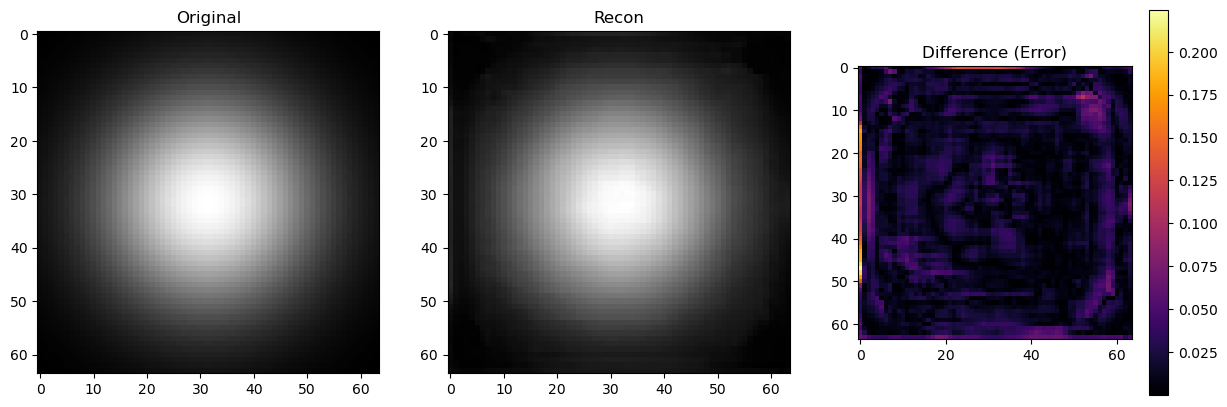

In [1]:
# 用一个 3D 图形来验证 VAE 的编码和解码效果
# 验证 stage1.ckpt 是否能正确工作

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# -----------------------------------------------------------------------------
# 1. 动态修补路径 (防止 Python 找不到 taming)
# -----------------------------------------------------------------------------
# 假设当前目录下有 taming 文件夹
sys.path.append(os.getcwd()) 

try:
    # 直接导入底层组件，绕过那个报错的 VQModel
    from taming.modules.diffusionmodules.model import Encoder, Decoder
    from taming.modules.vqvae.quantize import VectorQuantizer2 as VectorQuantizer
except ImportError:
    print("❌ 错误: 找不到 taming 模块。请确保你把 'taming' 文件夹放在了当前脚本的同一目录下。")
    exit()

# -----------------------------------------------------------------------------
# 2. 定义一个“干净”的 3D VQGAN 类 (只保留推理核心)
# -----------------------------------------------------------------------------
class Minimal3DVQModel(nn.Module):
    def __init__(self, 
                 ddconfig, 
                 n_embed, 
                 embed_dim):
        super().__init__()
        
        # 核心组件 1: 编码器 (引用现有的库)
        self.encoder = Encoder(**ddconfig)
        
        # 核心组件 2: 解码器 (引用现有的库)
        self.decoder = Decoder(**ddconfig)
        
        # 核心组件 3: 量化器
        self.quantize = VectorQuantizer(n_embed, embed_dim, beta=0.25)
        
        # 核心组件 4: 3D 卷积转换层 (关键！因为是 3D 模型)
        # 注意: 你的原始代码这里是 Conv3d
        self.quant_conv = nn.Conv3d(ddconfig["z_channels"], embed_dim, 1)
        self.post_quant_conv = nn.Conv3d(embed_dim, ddconfig["z_channels"], 1)

    def encode(self, x):
        h = self.encoder(x)
        h = self.quant_conv(h)
        quant, emb_loss, info = self.quantize(h)
        return quant

    def decode(self, quant):
        quant = self.post_quant_conv(quant)
        dec = self.decoder(quant)
        return dec

    def forward(self, x):
        quant = self.encode(x)
        dec = self.decode(quant)
        return dec

# -----------------------------------------------------------------------------
# 3. 配置与验证流程
# -----------------------------------------------------------------------------
def main():
    # === 用户配置区 ===
    CKPT_PATH = "vqgan/stage1.ckpt"
    DEPTH = 16  # 测试切片深度
    SIZE = 64   # 图片大小
    
    # 这里的参数来自 mar 仓库
    ddconfig = {
        "double_z": False,
        "z_channels": 4,
        "resolution": 256,
        "in_channels": 1,
        "out_ch": 1,
        "ch": 64,
        "num_groups": 32,
        "ch_mult": [1, 1, 2],
        "num_res_blocks": 1,
        "attn_resolutions": [],
        "dropout": 0.0
    }
    n_embed = 8192
    embed_dim = 4
    # =================
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 正在初始化纯净版模型 (Device: {device})...")
    
    try:
        model = Minimal3DVQModel(ddconfig, n_embed, embed_dim)
    except Exception as e:
        print(f"❌ 模型初始化失败: {e}")
        print("提示: 可能是 Encoder/Decoder 代码里的卷积层不支持 3D。如果报错是 Dimension 相关的，请告诉我。")
        return

    # --- 加载权重 ---
    if not os.path.exists(CKPT_PATH):
        print(f"❌ 找不到文件: {CKPT_PATH}")
        return

    print(f"📂 正在读取权重: {CKPT_PATH}")
    sd = torch.load(CKPT_PATH, map_location="cpu")
    if "state_dict" in sd:
        sd = sd["state_dict"]

    # 关键步骤: 过滤掉我们不需要的权重 (SPADE, Loss, Discriminator)
    # 我们只保留 encoder, decoder, quantize, quant_conv 相关的
    print("🧹 正在清理权重字典...")
    missing, unexpected = model.load_state_dict(sd, strict=False)
    
    # 验证是否加载了核心权重
    core_keys = ["encoder.conv_in.weight", "decoder.conv_out.weight", "quantize.embedding.weight"]
    loaded_keys = list(sd.keys())
    for key in core_keys:
        # 有些 ckpt 可能会有 "model." 前缀
        if key in loaded_keys or f"model.{key}" in loaded_keys:
            continue
        # 如果上面没找到，再检查一下 missing 列表
        is_missing = any(key in m for m in missing)
        if is_missing:
            print(f"⚠️ 警告: 核心权重 {key} 似乎缺失了！")

    print(f"✅ 权重加载完毕 (忽略了 {len(unexpected)} 个无关参数，如 SPADE/Loss)")
    model.to(device).eval()

    # --- 生成 3D 测试数据 (球体) ---
    # 1. 加大深度，避免边界效应
    DEPTH = 64  # 原来是 16，太薄了
    SIZE = 64
    
    print(f"🧊 生成 3D 测试数据 (Soft Sphere, Size: {SIZE}, Depth: {DEPTH})...")
    
    # 创建坐标网格
    x = np.linspace(-1, 1, SIZE)
    y = np.linspace(-1, 1, SIZE)
    z = np.linspace(-1, 1, DEPTH)
    xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')
    
    # 计算距离中心点的距离
    dist = np.sqrt(xx**2 + yy**2 + zz**2)
    
    # 2. 关键点：使用高斯函数生成“软球体”
    # 不要用 img[dist<r] = 1 这种硬切分
    # 这种数据平滑过渡，有纹理感，模型更容易重建
    img_3d = np.exp(-dist**2 / 0.4) 
    
    # 3. 稍微加一点点随机噪声，模拟真实的扫描噪点（可选，有时能帮助模型）
    # img_3d = img_3d + np.random.normal(0, 0.05, img_3d.shape)

    # 4. 严格归一化到 -1 到 1 之间 (VQGAN 的铁律)
    # 高斯函数输出是 0~1，我们需要映射到 -1~1
    img_3d = (img_3d * 2.0) - 1.0
    
    tensor = torch.from_numpy(img_3d).float().permute(2, 0, 1).unsqueeze(0).unsqueeze(0)
    tensor = tensor.to(device)

    # --- 推理 ---
    print("⚡ 开始推理 (Encode -> Decode)...")
    with torch.no_grad():
        try:
            encoded = model.encode(tensor)
            print(f"🔍 检查点 1: Latent Shape = {encoded.shape}")
            recon = model.decode(encoded)
        except RuntimeError as e:
            print(f"❌ 推理报错: {e}")
            print("如果报错是 'Expected 4-dimensional input'，说明 taming 库里的 Encoder 没改过，不支持 3D。")
            return

    # --- 干净推理 (不搞破坏) ---
    # with torch.no_grad():
    #     encoded = model.encode(tensor)
    #     # 😈 搞破坏：把 Latent 的左半边全部抹成 0
    #     destroyed_latent = encoded.clone()
    #     d, h, w = destroyed_latent.shape[2:]
    #     destroyed_latent[:, :, :, :, :w//2] = 0  # 抹掉宽度的一半
    #     recon = model.decode(destroyed_latent)
    #     # 保存坏掉的图
    #     mid_slice_bad = recon[0, 0, DEPTH//2].cpu().numpy()
    #     plt.imsave("verify_sabotage.png", mid_slice_bad, cmap="gray")
    #     print("😈 破坏测试图已保存为 verify_sabotage.png，请查看它是否只有一半！")


    # --- 可视化 ---
    print("💾 保存结果...")
    mid_slice_in = tensor[0, 0, DEPTH//2].cpu().numpy()
    mid_slice_out = recon[0, 0, DEPTH//2].cpu().numpy()

    # 计算差异
    diff = np.abs(mid_slice_in - mid_slice_out)
    
    print(f"📉 最大误差值: {diff.max():.6f}")
    print(f"📉 平均误差值: {diff.mean():.6f}")

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.title("Original"); plt.imshow(mid_slice_in, cmap="gray")
    plt.subplot(1, 3, 2); plt.title("Recon"); plt.imshow(mid_slice_out, cmap="gray")
    
    # 画出差异图 (使用热力图)
    plt.subplot(1, 3, 3); plt.title("Difference (Error)"); plt.imshow(diff, cmap="inferno") # inferno 颜色对比强烈
    plt.colorbar()
    
    plt.savefig("verify_diff.png")

if __name__ == "__main__":
    main()